# Task 2 — Decision Trees: Entropy, Over-fitting and a Logistic Regression Comparison
**Student:** Daniil Li  
**Student ID:** S24072175 (seed: 2175)  
**Group:** CSS3004-ENG-1

In [49]:
import sys

import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)

3.12.8 2.0.2 2.3.3 1.6.1


In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 2175

data = pd.read_csv("data/heart_disease.csv")
feature_names = [c for c in data.columns if c != "disease"]
X, y = data[feature_names].to_numpy(), data["disease"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)


(297, 14) 0.461 (207, 13) (90, 13)


### Part 1 - Entropy and information gain by hand

In [51]:
toy = pd.DataFrame({
    "age_55_plus": [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
    "exercise_angina": [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "male": [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    "high_bp": [1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
    "disease": [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
})
toy

,age_55_plus,exercise_angina,male,high_bp,disease
0,1,1,1,1,1
1,1,1,1,1,1
2,1,1,1,0,1
3,1,1,0,1,1
4,1,0,0,1,1
5,0,0,0,0,1
6,1,0,1,0,0
7,0,0,1,0,0
8,0,0,1,0,0
9,0,0,0,1,0


1. **Parent entropy.** 6 patients with disease and 6 without, so p = 6/12 = 0.5 on both classes:

H(parent) = -(6/12)·log2(6/12) - (6/12)·log2(6/12) = -0.5·(-1) - 0.5·(-1) = 1 bit.

2. **Information gain of each feature and the root.** Root entropy = 1 bit.

| feature            | children (left / right) | H(children)      | weighted H | gain   |
|--------------------|-------------------------|------------------|------------|--------|
| `age_55_plus`      | {5+,1-} / {1+,5-}       | 0.650 / 0.650    | 0.650      | 0.350  |
| `exercise_angina`  | {4+,0-} / {2+,6-}       | 0.000 / 0.811    | 0.541      | 0.459  |
| `male`             | {3+,3-} / {3+,3-}       | 1.000 / 1.000    | 1.000      | 0.000  |
| `high_bp`          | {4+,2-} / {2+,4-}       | 0.918 / 0.918    | 0.918      | 0.082  |

Worked example for `exercise_angina`: the left child (value 1) has 4 patients, all with disease -> H = 0;
the right child (value 0) has 8 patients, 2 with disease and 6 without ->
H = -(2/8)log2(2/8) - (6/8)log2(6/8) = 0.811.
Weighted child entropy = (4/12)·0 + (8/12)·0.811 = 0.541, so gain = 1 - 0.541 = 0.459.

Root = `exercise_angina`, the feature with the largest gain (0.459).

3. **One level down.** The left branch of the root (`exercise_angina = 1`) is pure (all 4 patients have
disease), so the impure branch is `exercise_angina = 0`: 8 patients, 2 with disease, H = 0.811.
Gains of the remaining three features inside that branch:

| feature         | children (left / right) | H(children)   | weighted H | gain   |
|-----------------|-------------------------|---------------|------------|--------|
| `male`          | {0+,3-} / {2+,3-}       | 0.000 / 0.971 | 0.607      | 0.204  |
| `age_55_plus`   | {1+,1-} / {1+,5-}       | 1.000 / 0.650 | 0.738      | 0.074  |
| `high_bp`       | {1+,2-} / {1+,4-}       | 0.918 / 0.722 | 0.796      | 0.016  |

`male` wins here with gain 0.204, although at the root it had gain 0.000.

A feature can look useless at the root and still be the best choice below it because information gain is
measured relative to the class distribution of the current node. At the root, splitting on `male` kept
a 50/50 mix on both sides, so nothing was gained; inside the `exercise_angina = 0` branch the mix is
different (2 positive out of 8), and there `male` cleanly isolates the negative cases.

### Part 2 - A decision tree from scratch

In [52]:
def entropy(y):
    """Entropy in bits of an array of integer class labels."""
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())


def information_gain(y, left):
    """Entropy of y minus the size-weighted entropy of y[left] and y[~left]; left is a boolean mask."""
    y = np.asarray(y)
    left = np.asarray(left, dtype=bool)
    n = len(y)
    n_left = int(left.sum())
    n_right = n - n_left
    if n_left == 0 or n_right == 0:
        return 0.0
    return float(entropy(y) - (n_left / n) * entropy(y[left]) - (n_right / n) * entropy(y[~left]))


def best_split(X, y, min_samples_leaf=1):
    """Return (feature_index, threshold, gain) of the best split, or None if no valid split exists."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    n, n_features = X.shape
    best_gain = -np.inf
    best = None
    for j in range(n_features):
        values = np.unique(X[:, j])
        thresholds = (values[:-1] + values[1:]) / 2.0  # midpoints, left = x <= t
        for t in thresholds:
            left = X[:, j] <= t
            n_left = int(left.sum())
            n_right = n - n_left
            if n_left < min_samples_leaf or n_right < min_samples_leaf:
                continue
            gain = information_gain(y, left)
            if gain > best_gain + 1e-12:  # ties keep the earlier (= lower feature, lower threshold) split
                best_gain = gain
                best = (j, float(t), float(gain))
    return best


def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Grow a tree recursively and return it as nested dicts."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    majority = int(classes[np.argmax(counts)])  # np.unique sorts, argmax -> smaller label on a tie
    if len(classes) == 1 or (max_depth is not None and depth >= max_depth):
        return {"leaf": True, "prediction": majority}
    split = best_split(X, y, min_samples_leaf=min_samples_leaf)
    if split is None:
        return {"leaf": True, "prediction": majority}
    j, t, gain = split
    left = X[:, j] <= t
    return {
        "leaf": False,
        "feature": j,
        "threshold": t,
        "left": build_tree(X[left], y[left], max_depth, min_samples_leaf, depth + 1),
        "right": build_tree(X[~left], y[~left], max_depth, min_samples_leaf, depth + 1),
    }


def predict_tree(tree, X):
    """Return one predicted label per row of X."""
    X = np.asarray(X, dtype=float)
    preds = np.empty(len(X), dtype=int)
    for i, row in enumerate(X):
        node = tree
        while not node["leaf"]:
            node = node["left"] if row[node["feature"]] <= node["threshold"] else node["right"]
        preds[i] = node["prediction"]
    return preds

In [53]:
from sklearn.tree import DecisionTreeClassifier

ref = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=SEED).fit(X_train, y_train)
print(feature_names[ref.tree_.feature[0]], ref.tree_.threshold[0])

cp 3.5


#### Q1: Run entropy and information_gain on the toy table of Part 1: do they reproduce your hand values?

In [54]:
y_toy = toy["disease"].to_numpy()
print("parent entropy:", round(entropy(y_toy), 4))
for feat in ["age_55_plus", "exercise_angina", "male", "high_bp"]:
    print(feat, round(information_gain(y_toy, toy[feat].to_numpy() == 1), 4))

parent entropy: 1.0
age_55_plus 0.35
exercise_angina 0.4591
male 0.0
high_bp 0.0817


Yes. On the 12 toy patients my `entropy` returns 1.0 and `information_gain` returns
age_55_plus = 0.350, exercise_angina = 0.459, male = 0.000, high_bp = 0.082 —
identical to the manual calculation, so the code and the hand computation agree.

#### Q2: Does your best_split on X_train, y_train choose the same feature and threshold as the line above?

In [55]:
print("my best_split:", best_split(X_train, y_train))

my best_split: (2, 3.5, 0.21463261530665523)


Yes. `best_split(X_train, y_train)` returns feature index 2 (`cp`), threshold 3.5, gain 0.215,
and scikit-learn's depth-1 tree with `criterion="entropy"` splits on the same feature and threshold (`cp`,
3.5). My midpoint thresholds and scikit-learn's impurity search picked the same cut on this training split.

#### Q3. For max_depth = 1, 2, 3, 4, 5 and unlimited, build your tree and scikit-learn's (criterion="entropy", same depth, random_state=SEED) and print the fraction of test rows on which the two predict the same label. If it is below 100% anywhere, explain in a sentence what could cause it.

In [56]:
rows = []
for d in [1, 2, 3, 4, 5, None]:
    my_pred = predict_tree(build_tree(X_train, y_train, max_depth=d), X_test)
    sk_pred = DecisionTreeClassifier(
        criterion="entropy", max_depth=d, random_state=SEED
    ).fit(X_train, y_train).predict(X_test)
    rows.append((d, float(np.mean(my_pred == sk_pred))))
agreement = pd.DataFrame(rows, columns=["max_depth", "agreement"])
agreement

,max_depth,agreement
0,1.0,1.0
1,2.0,1.0
2,3.0,1.0
3,4.0,1.0
4,5.0,1.0
5,NaN,1.0


Every depth agrees on 100% of the test rows, so there is no disagreement to explain: for this training
split the two implementations chose the same feature/threshold at each node, and where two candidate splits
were tied my "lower feature index, then lower threshold" rule happened to give the same result as
scikit-learn's random tie-break (`random_state=SEED`).

### Part 3 - How deep should the tree be?

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED)
scores = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy", return_train_score=True)
print(scores["train_score"].mean(), scores["test_score"].mean(), scores["test_score"].std())

0.875618838992333 0.8074332171893147 0.07720004762677014


#### 3a) Depth sweep

In [58]:
rows = []
for d in [1, 2, 3, 4, 5, 6, 8, 10, None]:
    m = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED)
    s = cross_validate(m, X_train, y_train, cv=cv, scoring="accuracy", return_train_score=True)
    m.fit(X_train, y_train)
    rows.append({
        "max_depth": d,
        "leaves": m.get_n_leaves(),
        "train_acc": s["train_score"].mean(),
        "cv_acc": s["test_score"].mean(),
        "cv_std": s["test_score"].std(),
    })
sweep = pd.DataFrame(rows)
sweep["max_depth"] = sweep["max_depth"].apply(lambda d: "None" if pd.isna(d) else int(d))
sweep

,max_depth,leaves,train_acc,cv_acc,cv_std
0,1,2,0.771734,0.739257,0.034340
1,2,4,0.788653,0.763182,0.061684
2,3,8,0.875619,0.807433,0.077200
3,4,15,0.905827,0.749129,0.070659
4,5,22,0.960161,0.773403,0.070552
5,6,27,0.981891,0.787805,0.063623
6,8,30,0.996386,0.783391,0.073760
7,10,30,1.000000,0.783391,0.073760
8,None,30,1.000000,0.783391,0.073760


#### 3b) Plot

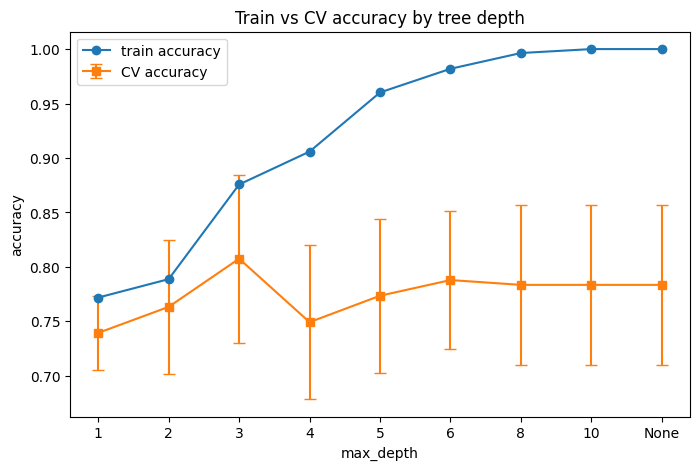

In [59]:
import matplotlib.pyplot as plt

x = np.arange(len(sweep))
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(x, sweep["train_acc"], marker="o", label="train accuracy")
ax.errorbar(x, sweep["cv_acc"], yerr=sweep["cv_std"], marker="s", capsize=4, label="CV accuracy")
ax.set_xticks(x)
ax.set_xticklabels(sweep["max_depth"])
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Train vs CV accuracy by tree depth")
ax.legend()
plt.show()

#### 3c) Choosing a depth

Selection rule. I use the one-standard-error rule: I take the depth with the highest mean CV accuracy
and step down by one standard error of the mean (fold std / sqrt(5)); among the depths still inside that
band I pick the *simplest* one. This uses the spread over the folds instead of trusting a single best mean.

Applying it: the best mean CV accuracy is 0.807 at max_depth = 3 (fold std 0.077, so SE = 0.077/sqrt(5) =
0.034). Band = 0.807 - 0.034 = 0.773. The depths whose mean CV accuracy is at least 0.773 are 3 (0.807),
5 (0.773), 6 (0.788) and 8, 10 and None (all 0.783); the simplest of them is **max_depth = 3**, so I choose
depth 3.

Is it clearly better than its neighbours? No. Depth 2 (0.763) and depth 4 (0.749) are lower, but the gap to
depth 2 (0.044) and to depth 4 (0.058) are both smaller than the fold standard deviation (~0.077), so
depth 3 gives the best mean but is not separated from its neighbours by more than the noise between folds

#### 3d) A second brake

In [60]:
rows = []
for m_ in [1, 2, 5, 10, 20, 40]:
    m = DecisionTreeClassifier(criterion="entropy", max_depth=None, min_samples_leaf=m_, random_state=SEED)
    s = cross_validate(m, X_train, y_train, cv=cv, scoring="accuracy", return_train_score=True)
    m.fit(X_train, y_train)
    rows.append({
        "min_samples_leaf": m_,
        "leaves": m.get_n_leaves(),
        "train_acc": s["train_score"].mean(),
        "cv_acc": s["test_score"].mean(),
        "cv_std": s["test_score"].std(),
    })
msl = pd.DataFrame(rows)
msl

,min_samples_leaf,leaves,train_acc,cv_acc,cv_std
0,1,30,1.000000,0.783391,0.073760
1,2,29,0.973443,0.764111,0.079841
2,5,19,0.902169,0.797445,0.084061
3,10,12,0.873195,0.797561,0.060325
4,20,8,0.788653,0.763182,0.061684
5,40,4,0.771734,0.739257,0.034340


With unlimited depth but a minimum leaf size, the best mean CV accuracy is at min_samples_leaf = 10
(0.798, 12 leaves), statistically tied with min_samples_leaf = 5 (0.797, 19 leaves) — the two means differ
by 0.0001, far less than the fold spread. With min_samples_leaf = 1 (i.e. no brake at all) the training
accuracy is 1.000 while the CV accuracy is only 0.783, the same over-fitting we saw at max_depth = None.

Comparing the two brakes: max_depth limits how many questions the tree may ask in a row (its best CV came
at depth 3, 8 leaves) and gives compact, easy-to-read trees; min_samples_leaf limits how small a leaf may
become and keeps depth wherever it still helps (best CV at 12-19 leaves). Once a brake is actually applied,
both stop the training accuracy from reaching 1.0, so they are two routes to the same goal. The difference
between their best CV means (0.807 vs 0.798) is inside the fold spread, so neither is clearly better here.

#### 3e) Test once

In [61]:
chosen_depth = 3

final_tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=chosen_depth, random_state=SEED
).fit(X_train, y_train)
test_acc = final_tree.score(X_test, y_test)
se = np.sqrt(test_acc * (1 - test_acc) / len(y_test))
print("test accuracy:", round(test_acc, 3), "std error:", round(se, 3))

test accuracy: 0.8 std error: 0.042


Fitting the chosen depth-3 tree on the full training split gives a test accuracy of 0.800, with standard
error sqrt(0.800·(1-0.800)/90) = 0.042. So the test accuracy is 0.800 ± 0.042, consistent with the mean CV
accuracy of 0.807.

At max_depth = None the training accuracy reaches 1.000 while the CV accuracy is only 0.783: a gap of
about 0.22 means the unlimited tree has memorised the training patients and does not generalise.

### Part 4 - Tree or logistic regression?

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
scores = cross_validate(logreg, X_train, y_train, cv=cv, scoring=("accuracy", "f1"))
print(scores["test_accuracy"].mean(), scores["test_accuracy"].std(), scores["test_f1"].mean())

0.8259001161440185 0.029346539213531753 0.8062682365332823


#### 4a) Cross-validation

In [63]:
models = {
    "tree (chosen depth)": DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED),
    "tree (unlimited)": DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=SEED),
    "logreg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
}
rows = []
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=("accuracy", "f1"))
    rows.append({
        "model": name,
        "cv_acc_mean": s["test_accuracy"].mean(),
        "cv_acc_std": s["test_accuracy"].std(),
        "cv_f1_mean": s["test_f1"].mean(),
    })
cv_table = pd.DataFrame(rows)
cv_table

,model,cv_acc_mean,cv_acc_std,cv_f1_mean
0,tree (chosen depth),0.807433,0.077200,0.777234
1,tree (unlimited),0.783391,0.073760,0.754639
2,logreg,0.825900,0.029347,0.806268


#### 4b) Does a tree need scaling? 

In [64]:
tree_raw = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED).fit(X_train, y_train)

scaler = StandardScaler().fit(X_train)
tree_scaled = DecisionTreeClassifier(
    criterion="entropy", max_depth=chosen_depth, random_state=SEED
).fit(scaler.transform(X_train), y_train)

agree = np.mean(tree_raw.predict(X_test) == tree_scaled.predict(scaler.transform(X_test)))
print("agreement:", agree)

agreement: 1.0


The two trees agree on 100% of the test rows (agreement = 1.0). A decision tree only ever asks
"is feature x <= threshold t?", and standardising a feature subtracts its mean and divides by its
standard deviation, a monotone transformation that does not change the order of the values. So the same
splits are found and every test row falls into the same leaf, i.e. scaling leaves the tree completely
unchanged. This is the opposite of what we saw for logistic regression, where the scaler belongs inside
the pipeline.

#### 4c) Hold-out, once (90 test patients)

In [65]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

logreg.fit(X_train, y_train)
for name, m in [("tree", tree_raw), ("logreg", logreg)]:
    pred = m.predict(X_test)
    acc = accuracy_score(y_test, pred)
    se = np.sqrt(acc * (1 - acc) / len(y_test))
    print(name, "accuracy", round(acc, 3), "std error", round(se, 3),
          "f1", round(f1_score(y_test, pred), 3))
    print(confusion_matrix(y_test, pred))

tree accuracy 0.8 std error 0.042 f1 0.763
[[43  5]
 [13 29]]
logreg accuracy 0.844 std error 0.038 f1 0.825
[[43  5]
 [ 9 33]]


| model  | accuracy | std error | F1    | confusion matrix (rows = true [0,1], cols = predicted [0,1]) |
|--------|----------|-----------|-------|-------------------------------------------------------------|
| tree   | 0.800    | 0.042     | 0.763 | [[43, 5], [13, 29]]  ->  TN=43, FP=5, FN=13, TP=29          |
| logreg | 0.844    | 0.038     | 0.825 | [[43, 5], [9, 33]]   ->  TN=43, FP=5, FN=9,  TP=33          |

Both models make the same 5 false positives; the difference is in the false negatives the tree misses 13
patients who have the disease, the logistic regression only 9

#### 4d) Conclusion

In cross-validation logistic regression has the best mean accuracy (0.826 ± 0.029, F1 0.806); the depth-3
tree scores 0.807 ± 0.077 (F1 0.777) and the unlimited tree 0.783 ± 0.074 (F1 0.755). On the test split
logistic regression is ahead again, 0.844 ± 0.038 (F1 0.825) versus 0.800 ± 0.042 for the tree (F1 0.763).
These gaps sit inside the noise: 0.044 on the test, where the combined standard error is
sqrt(0.038² + 0.042²) = 0.057, and 0.019 between the CV means, smaller than the tree's fold spread of 0.077.
The only clear difference is stability, since the regression varies much less across folds (std 0.029 vs
0.077). I would use logistic regression, while admitting its accuracy advantage is not established

### Part 5 - Reading a tree, and reproducibility

In [66]:
from sklearn.tree import export_text

shallow = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED).fit(X_train, y_train)
print(export_text(shallow, feature_names=feature_names))
ranked = sorted(zip(shallow.feature_importances_, feature_names), reverse=True)
print([(name, round(float(imp), 3)) for imp, name in ranked[:5]])

print("n_node_samples:", shallow.tree_.n_node_samples)
print("leaf class counts:", (shallow.tree_.value.reshape(-1, 2) * shallow.tree_.n_node_samples[:, None]).round().astype(int))

|--- cp <= 3.50
|   |--- thal <= 4.50
|   |   |--- age <= 56.50
|   |   |   |--- class: 0
|   |   |--- age >  56.50
|   |   |   |--- class: 0
|   |--- thal >  4.50
|   |   |--- thalach <= 143.50
|   |   |   |--- class: 1
|   |   |--- thalach >  143.50
|   |   |   |--- class: 0
|--- cp >  3.50
|   |--- ca <= 0.50
|   |   |--- thal <= 6.50
|   |   |   |--- class: 0
|   |   |--- thal >  6.50
|   |   |   |--- class: 1
|   |--- ca >  0.50
|   |   |--- exang <= 0.50
|   |   |   |--- class: 1
|   |   |--- exang >  0.50
|   |   |   |--- class: 1

[('cp', 0.389), ('thal', 0.244), ('ca', 0.2), ('age', 0.084), ('thalach', 0.056)]
n_node_samples: [207 114  82  58  24  32  10  22  93  40  21  19  53  19  34]
leaf class counts: [[112  95]
 [ 89  25]
 [ 74   8]
 [ 57   1]
 [ 17   7]
 [ 15  17]
 [  1   9]
 [ 14   8]
 [ 23  70]
 [ 21  19]
 [ 17   4]
 [  4  15]
 [  2  51]
 [  2  17]
 [  0  34]]


#### 1) Two rules

Rule predicting disease: if cp > 3.5 (asymptomatic chest pain) AND ca > 0.5 (at least one major vessel
coloured by fluoroscopy) AND exang > 0.5 (exercise-induced angina present), then the tree predicts disease
(class 1). 34 training patients reach this leaf and all 34 have the disease.

Rule predicting no disease: if cp <= 3.5 (chest pain is not asymptomatic) AND thal <= 4.5 (thal = normal)
AND age <= 56.5, then the tree predicts no disease (class 0). 58 training patients reach this leaf, 57
without the disease and 1 with it.

#### 2) Importances

The five most important features of the depth-3 tree are cp (0.389), thal (0.244), ca (0.200), age (0.084)
and thalach (0.056).

Limitation: feature_importances_ just sums how much a feature reduced impurity when the tree chose to split
on it, so it is not a causal effect, it does not show the direction of the effect, and it is biased towards
features with many distinct values (more possible split points). A small value does not mean the feature is
irrelevant, only that this tree did not need it.


#### 3) A split whose two children predict the same class

In this tree the node "cp > 3.5 AND ca > 0.5" (53 training patients, 2 without and 51 with the disease) is
split again on exang, and both children predict class 1 (19 patients and 34 patients). scikit-learn picks a
split by the largest decrease in impurity (here entropy, i.e. the largest information gain), not by whether
the predicted label of the children changes, so it still takes this split: the parent entropy is about 0.23
bits and the split lowers it to about 0.17 bits, because the right child becomes pure (34 of 34 with the
disease). The split is useful for the quantity sklearn optimises and can help the splits below it, even
though it looks redundant when you read only the predicted classes.
